In [1]:
# Import dependencies:
import xarray as xr

**EC-Earth**

In [ ]:
fpath="/g100/home/userexternal/otooth00/OptimESM/data/CINECA/SMHI/EC-Earth_Ofx/mesh_mask_Ofx_EC-Earth.nc"
ds = xr.open_dataset(fpath)
ds


In [ ]:
(((ds.longitude + 180) % 360) - 180).plot()

**IPSL**

In [ ]:
fpath = "/g100/home/userexternal/otooth00/OptimESM/data/CINECA/IPSL/IPSL_Ofx/mesh_mask_Ofx_IPSL.nc"
ds = xr.open_dataset(fpath)

ds

In [ ]:
(((ds.longitude + 180) % 360) - 180).plot()

**CNRM**

In [ ]:
fpath="/g100/home/userexternal/otooth00/OptimESM/data/CINECA/CNRM/CNRM_Ofx/mesh_mask_Ofx_CNRM.nc"

ds = xr.open_dataset(fpath)
ds

In [ ]:
ds.longitude.plot()

**Testing IHO World Seas Masks**

In [2]:
dirpath = "/g100_work/optim_IAC/research/noc/otooth/OptimESM_IHO/masks"

ds_mask = xr.open_dataset(f"{dirpath}/UKESM1-2_World_Seas_IHO_v3_mask.nc")
ds_mask

<xarray.Dataset> Size: 976kB
Dimensions:    (y: 330, x: 360, id: 101)
Coordinates:
  * id         (id) int64 808B 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99 100
Dimensions without coordinates: y, x
Data variables:
    mask_iho   (y, x) float64 950kB ...
    name_iho   (id) <U59 24kB ...
    mrgid_iho  (id) int64 808B ...

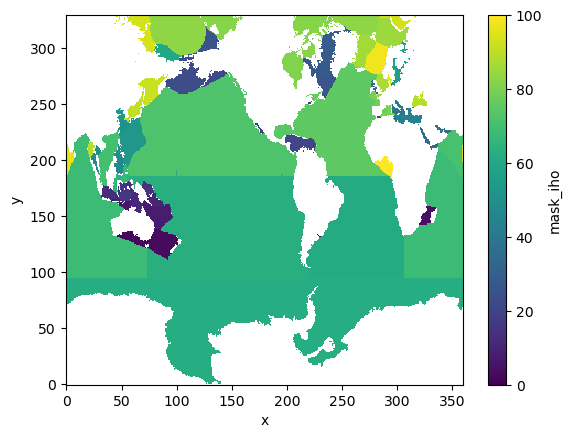

In [3]:
ds_mask.mask_iho.plot()

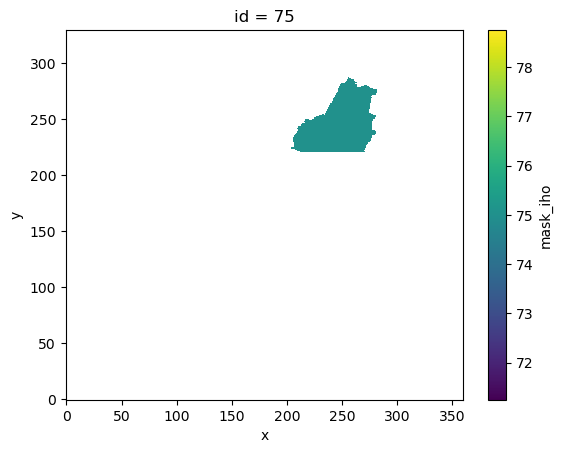

In [5]:
# Get mask ID (integer) for North Atlantic Ocean:
mask_id = ds_mask["id"][ds_mask["name_iho"] == "North Atlantic Ocean"]

# Plot DataArray {my_var} for only North Atlantic Ocean IHO area:
combined_mask = (ds_mask["mask_iho"] == mask_id) & (ds_mask['y'] > 220)
ds_mask["mask_iho"].where(combined_mask).plot()